In [486]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [487]:
df = pd.read_csv('../data/cleaned_data.csv')
df.head()

,Outcome,Task Completed,All Tasks Completed,Murdered,Imposter Kills,Ejected,Sabotages Fixed,Game Length (s),Task Time (s),is_imposter
0,1,3.0,0,1.0,0.0,0.0,2.0,424,0.0,0
1,0,7.0,1,0.0,0.0,0.0,1.0,981,588.0,0
2,1,3.0,0,0.0,0.0,0.0,0.0,693,0.0,0
3,1,0.0,0,0.0,2.0,0.0,0.0,485,0.0,1
4,0,4.0,0,0.0,0.0,0.0,0.0,310,0.0,0


In [488]:
#define features of interest and target
X = df[['All Tasks Completed','Ejected', 'Sabotages Fixed', 'Game Length (s)', 'Task Time (s)']]
#dropped Outcome and Murdered because not needed
#dropped Tasks Completed and Imposter Kills because of data leakage

y = df['is_imposter']

In [489]:
#split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

#verify split worked correctly
print(X_train.shape) #expected: 1781 (80%)
print(X_test.shape) #expected: 446 (20%)

(1781, 5)
(446, 5)


In [490]:
'''
Models to Choose From:
1. Logistic Regression
    -> classifier
    -> draws a line between seperate classes

2. Decision Tree ***Use this first then random forest to get more accurate
    -> asks yes/no questions about features to make prediction

3. Random Forest
    -> builds many decision trees and combines their predictions
    -> more accurate than a single tree
'''

#test using decision tree - BASELINE
dtm = DecisionTreeClassifier()
dtm.fit(X_train,y_train)

#predict using decision tree
X_predictions = dtm.predict(X_test)
print(X_predictions)

#compare predictions to actual values in y_test
accuracy = accuracy_score(y_test, X_predictions)
print(accuracy)

[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0
 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 1 1 0 1 0 0 0 1 1 0 0
 0 0]
0.8139013452914798


In [491]:
'''
Confusion Matrix
    Predicted Crewmate    Predicted Imposter
Actual Crewmate       TN                    FP
Actual Imposter       FN                    TP

TN (True Negative) — correctly predicted Crewmate
TP (True Positive) — correctly predicted Imposter
FP (False Positive) — predicted Imposter but was actually Crewmate
FN (False Negative) — predicted Crewmate but was actually Imposter
'''
#creating confusion matrix
confusion = confusion_matrix(y_test, X_predictions)
print(confusion)

[[320  33]
 [ 50  43]]


In [492]:
#identifying which feature the model relies on the most
relying_attribute = dtm.feature_importances_
for feature, importance in zip(X.columns, relying_attribute):
    print(feature,importance)

All Tasks Completed 0.0
Ejected 0.039099924250260716
Sabotages Fixed 0.13195546696270108
Game Length (s) 0.6413929211778775
Task Time (s) 0.18755168760916066


In [493]:
#Random Forest Model - FINAL MODEL
rfm = RandomForestClassifier(class_weight='balanced')
rfm.fit(X_train, y_train)

X_predictions = rfm.predict(X_test)
print(X_predictions)

accuracy = accuracy_score(X_predictions, y_test)
print(accuracy)

confusion = confusion_matrix(y_test, X_predictions)
print(confusion)

relying_attribute = rfm.feature_importances_
for feature, importance in zip(X.columns, relying_attribute):
    print(feature,importance)


[0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0
 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0
 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 1
 1 0 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0
 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 1 1 0 1 0 0 1 1 1 0 0
 1 0]
0.804932735426009
[[304  49]
 [ 38  55]]
All Tasks Completed 0.11959970593330374
Ejected 0.025

Text(0.5, 1.0, 'Confusion Matrix')

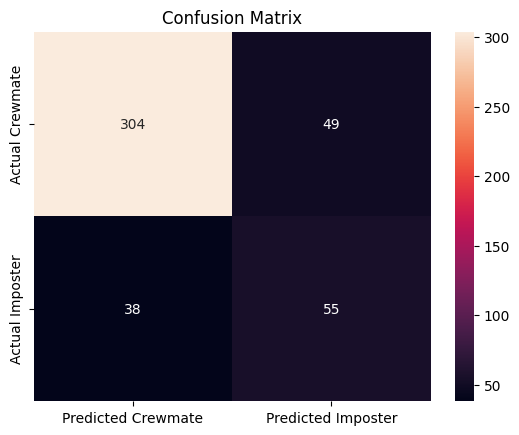

In [494]:
'''
In this case we would choose to use the random forest model because the accuracy is around
the same and is more robust than a single decision tree since its less likely to overfit on
new data
'''

#Visulaizing Random Forest Model

#confusion matrix
sns.heatmap(confusion, xticklabels=['Predicted Crewmate','Predicted Imposter'], yticklabels = ['Actual Crewmate', 'Actual Imposter'], annot=True, fmt='d')
plt.title('Confusion Matrix')

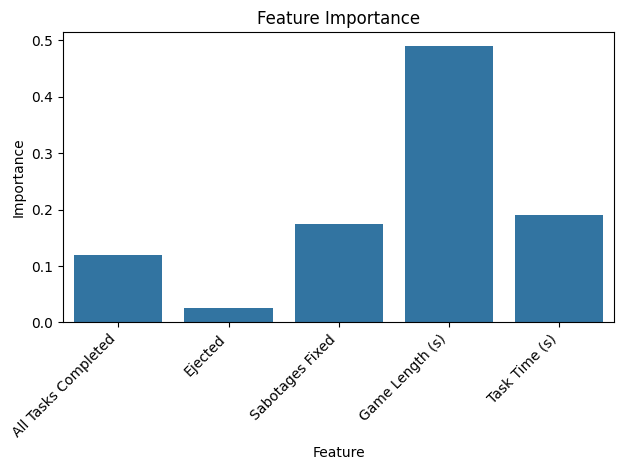

In [495]:
#feature importance bar graph
data = pd.DataFrame({'Feature': X.columns, 'Importance': rfm.feature_importances_})
sns.barplot(x = 'Feature', y= 'Importance', data = data,)
plt.title("Feature Importance")
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()